In [ ]:
!pip install torchinfo

In [ ]:
import torch
from torch import nn
import torchvision
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, TensorDataset

from torchsummary import summary
import torchinfo

In [ ]:
import os
import urllib.request
import zipfile
import tarfile
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'  #only train and validate data present

dataset_path = "/content/cats_and_dogs_filtered.zip"
extract_path = "/content/"

# Download the dataset
print("Downloading  dataset...")
urllib.request.urlretrieve(url, dataset_path)
print("Download complete.")


# Extract the dataset
print("Extracting Dataset")
with zipfile.ZipFile(dataset_path, 'r') as zf:
    zf.extractall(extract_path)
print("Extraction Complete")

# Verify extraction
print("Dataset files:", os.listdir(extract_path))

Download complete.
Extracting Dataset
Extraction Complete
Dataset files: ['.config', 'cats_and_dogs_filtered.zip', 'cats_and_dogs_filtered', 'sample_data']


In [ ]:
# data = torch.hub.download_url_to_file(url, extract_path)

100%|██████████| 65.4M/65.4M [00:00<00:00, 213MB/s]


In [ ]:
os.listdir()

['.config',
 'cats_and_dogs_filtered.zip',
 'cats_and_dogs_filtered',
 'sample_data']

In [ ]:
train = os.path.join(extract_path, 'cats_and_dogs_filtered/train')
print(train)
validation = os.path.join(extract_path, 'cats_and_dogs_filtered/validation')
print(validation)

/content/cats_and_dogs_filtered/train
/content/cats_and_dogs_filtered/validation


In [ ]:
# Define data transformations (e.g., resizing, normalization)
data_transforms = transforms.Compose([
    # transforms.Resize((22184, 224)),  # Resize images to a common size
    transforms.Resize((180, 180)),
    transforms.ToTensor(),          # Convert images to tensors
    # transforms.Normalize(mean=[0,0,0], std=[0,0,0]) # Normalize image data
])

Transforms for efficient net


In [ ]:
transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

In [ ]:
# Create datasets using ImageFolder
train_dataset = ImageFolder(train, transform=data_transforms)
validation_dataset = ImageFolder(validation, transform=data_transforms)


In [ ]:
batch_size = 64
torch.manual_seed(42)

trainloader = DataLoader(train_dataset, batch_size,shuffle= True)
validationloader = DataLoader(validation_dataset, batch_size, shuffle= True)

In [ ]:
# Define class names
classes = ('cats', 'dogs')

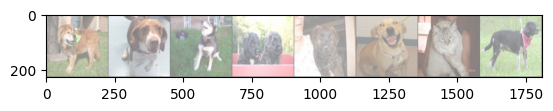

Labels: ['dogs', 'dogs', 'dogs', 'dogs', 'dogs', 'dogs', 'cats', 'dogs']


In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Function to unnormalize and display images
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Convert from Tensor to image
    plt.show()

# Display some images
imshow(torchvision.utils.make_grid(images[:8]))
print("Labels:", [classes[labels[i]] for i in range(8)])

In [ ]:
for X,y in trainloader:
   print(f"Shape of X [N, C, H, W]: {X.shape}")
   print(f"Shape of y: {y.shape} {y.dtype}")
   break

Shape of X [N, C, H, W]: torch.Size([64, 3, 224, 224])
Shape of y: torch.Size([64]) torch.int64


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cpu device


## Model

In [ ]:
class CNN_Model(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels= 32, kernel_size= 3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size= 2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels= 64, kernel_size= 3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size= 2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels= 128, kernel_size= 3)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size= 2)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels= 256, kernel_size= 3)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size= 2)
        self.conv5 = nn.Conv2d(in_channels=256, out_channels= 256, kernel_size= 3)
        self.relu5 = nn.ReLU()
        self.pool5 = nn.MaxPool2d(kernel_size= 2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features= 256 * 3 * 3, out_features= 64)  # 2304 foud from error from summary
        self.relu6 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(in_features= 64, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))
        x = self.pool5(self.relu5(self.conv5(x)))
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu6(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.sigmoid(x)

        return x

# Instantiate the model
cnn_model = CNN_Model().to(device)
print(cnn_model)

CNN_Model(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (relu4): ReLU()
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (relu5): ReLU()
  (pool5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2304, out_features=64, bias=True)
  (relu6): ReLU()
  (dropout): Dropout(p=0.5, inplac

In [ ]:
summary(cnn_model, input_size = (3, 180, 180), batch_size = -1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 178, 178]             896
              ReLU-2         [-1, 32, 178, 178]               0
         MaxPool2d-3           [-1, 32, 89, 89]               0
            Conv2d-4           [-1, 64, 87, 87]          18,496
              ReLU-5           [-1, 64, 87, 87]               0
         MaxPool2d-6           [-1, 64, 43, 43]               0
            Conv2d-7          [-1, 128, 41, 41]          73,856
              ReLU-8          [-1, 128, 41, 41]               0
         MaxPool2d-9          [-1, 128, 20, 20]               0
           Conv2d-10          [-1, 256, 18, 18]         295,168
             ReLU-11          [-1, 256, 18, 18]               0
        MaxPool2d-12            [-1, 256, 9, 9]               0
           Conv2d-13            [-1, 256, 7, 7]         590,080
             ReLU-14            [-1, 25

In [33]:
for param in cnn_model.parameters():
    print(param)

Parameter containing:
tensor([[[[ 6.4610e-02,  7.3479e-02,  3.0445e-02],
          [-8.7868e-02, -1.8889e-01,  5.4078e-02],
          [ 1.5324e-01,  1.2747e-01,  7.3150e-02]],

         [[-5.7893e-02, -3.6363e-04,  1.4871e-02],
          [-4.7087e-02,  1.8617e-01, -9.4203e-02],
          [-3.0058e-02,  2.0306e-02, -1.9030e-01]],

         [[ 2.2695e-02, -6.1164e-02, -8.0577e-02],
          [-4.9128e-03,  1.4284e-01, -1.6106e-01],
          [-8.0417e-02,  1.0516e-01, -1.3914e-01]]],


        [[[ 1.1642e-01, -5.2575e-02, -1.0003e-02],
          [-1.7485e-01, -1.6512e-01, -2.2690e-02],
          [ 7.7282e-02, -9.0480e-02, -3.5451e-02]],

         [[ 4.9884e-03, -1.8444e-01,  1.4129e-01],
          [-1.4878e-01, -1.9873e-02,  7.0026e-02],
          [-1.3045e-01,  1.2996e-01,  8.4790e-02]],

         [[ 9.0944e-02,  5.5455e-02, -1.2694e-01],
          [-1.8381e-01, -6.5481e-02,  1.2231e-02],
          [-3.4865e-02,  1.4199e-01,  6.8599e-02]]],


        [[[-6.9713e-02, -1.7125e-01, -1.5515

In [ ]:
loss_fn = nn.BCELoss()
num_epochs = 10

In [ ]:
optimizer = torch.optim.Adam(params= cnn_model.parameters(), lr= 0.001)

## Training

In [ ]:
torch.manual_seed(42)
results = []

def train_n_test(model, num_epochs,train_dl, test_dl):
    train_loss = [0]* num_epochs
    train_accuracy = [0]* num_epochs
    val_loss = [0]* num_epochs
    val_accuracy = [0]* num_epochs

    for epoch in range(num_epochs):
        #train
        model.train()
        for X_batch, y_batch in train_dl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_batch = y_batch.type(torch.float32)   # BCELoss expects data of type Float

            pred = model(X_batch)
            pred = pred.squeeze(1) # change the shape of the prediction from [batch_size, 1] to [batch_size]
            pred = torch.clamp(pred, 0, 1)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss[epoch] += loss.item() * y_batch.size(0)
            # iss_correct = (torch.argmax(pred, dim=1) == y_batch).float()
            iss_correct = ((pred > 0.5) == y_batch).float()
            train_accuracy[epoch] += iss_correct.sum().cpu()

        train_loss[epoch] /= len(train_dl.dataset)
        train_accuracy[epoch] /= len(train_dl.dataset)


        #Validate
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_batch = y_batch.type(torch.float32)

                pred = model(X_batch)
                pred = pred.squeeze(1) # change the shape of the prediction from [batch_size, 1] to [batch_size]
                pred = torch.clamp(pred, 0, 1)
                loss = loss_fn(pred, y_batch)

                val_loss[epoch] += loss.item() * y_batch.size(0)
                # iss_correct = (torch.argmax(pred, dim=1) == y_batch).float()
                iss_correct = ((pred > 0.5)  == y_batch).float()
                val_accuracy[epoch] += iss_correct.sum().cpu()

            val_loss[epoch]     /= len(test_dl.dataset)
            val_accuracy[epoch] /= len(test_dl.dataset)

        print(f"Epoch {epoch+1} Train accuracy: {train_accuracy} val accuracy: {val_accuracy}")
        #  print(f'Epoch {epoch+1} accuracy: {train_accuracy[epoch]:.4f} val_accuracy: {val_accuracy[epoch]:.4f}')
    return(train_loss, val_loss, train_accuracy, val_accuracy)

In [ ]:
history = train_n_test(cnn_model, num_epochs, trainloader, validationloader)

Epoch 1 Train accuracy: [tensor(0.6125), 0, 0, 0, 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.6660), 0, 0, 0, 0, 0, 0, 0, 0, 0]
Epoch 2 Train accuracy: [tensor(0.6125), tensor(0.6335), 0, 0, 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.6660), tensor(0.6340), 0, 0, 0, 0, 0, 0, 0, 0]
Epoch 3 Train accuracy: [tensor(0.6125), tensor(0.6335), tensor(0.6475), 0, 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.6660), tensor(0.6340), tensor(0.6100), 0, 0, 0, 0, 0, 0, 0]
Epoch 4 Train accuracy: [tensor(0.6125), tensor(0.6335), tensor(0.6475), tensor(0.6500), 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.6660), tensor(0.6340), tensor(0.6100), tensor(0.6320), 0, 0, 0, 0, 0, 0]
Epoch 5 Train accuracy: [tensor(0.6125), tensor(0.6335), tensor(0.6475), tensor(0.6500), tensor(0.6710), 0, 0, 0, 0, 0] val accuracy: [tensor(0.6660), tensor(0.6340), tensor(0.6100), tensor(0.6320), tensor(0.6410), 0, 0, 0, 0, 0]
Epoch 6 Train accuracy: [tensor(0.6125), tensor(0.6335), tensor(0.6475), tensor(0.6500), tensor(0.6710), tenso

## Plot Figure

In [ ]:
def plot_fig(history):
    train_loss, val_loss, train_accuracy, val_accuracy = history # unpack the tuple
    fig = plt.figure(figsize=(12,4))
    ax= fig.add_subplot(1,2,1)

    # Access the loss and accuracy directly from the unpacked variables
    plt.plot(train_loss, lw=3, label= 'Train loss')
    plt.plot(val_loss, lw=3, label ='Val Loss' )
    plt.legend(['Train loss', 'Val Loss'], fontsize=15)
    ax.set_xlabel('Epochs', size=15)
    ax.set_ylabel('Loss', size=15)

    ax= fig.add_subplot(1,2,2)
    plt.plot(train_accuracy, lw=3)
    plt.plot(val_accuracy, lw=3)
    plt.legend(['Train Accuracy', 'Validation Accuracy'], fontsize=15) # changed to reflect actual metrics
    ax.set_ylabel('Accuracy', size=15)
    ax.set_xlabel('Epochs', size=15)

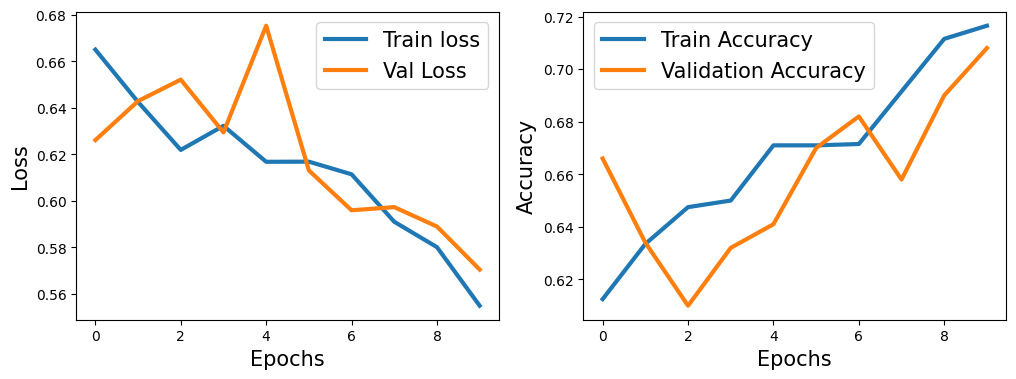

In [ ]:
plot_fig(history)

## Transfer Learning - pretrained Efficientnet v2

In [ ]:
from torchvision import models

efficient_net_model = models.efficientnet_v2_s(pretrained = True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:01<00:00, 50.7MB/s]


In [ ]:
# for name, module in  return self.model.classifier[-1].named_modules():
#     print(name, module)

efficient_net_model.classifier[-1]

Linear(in_features=1280, out_features=1000, bias=True)

In [ ]:
summary(efficient_net_model, input_size = (3, 180, 180), batch_size = -1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 24, 90, 90]             648
       BatchNorm2d-2           [-1, 24, 90, 90]              48
              SiLU-3           [-1, 24, 90, 90]               0
            Conv2d-4           [-1, 24, 90, 90]           5,184
       BatchNorm2d-5           [-1, 24, 90, 90]              48
              SiLU-6           [-1, 24, 90, 90]               0
   StochasticDepth-7           [-1, 24, 90, 90]               0
       FusedMBConv-8           [-1, 24, 90, 90]               0
            Conv2d-9           [-1, 24, 90, 90]           5,184
      BatchNorm2d-10           [-1, 24, 90, 90]              48
             SiLU-11           [-1, 24, 90, 90]               0
  StochasticDepth-12           [-1, 24, 90, 90]               0
      FusedMBConv-13           [-1, 24, 90, 90]               0
           Conv2d-14           [-1, 96,

In [ ]:
for name, module in reversed(list(efficient_net_model.named_children())):
    print(name, module)

classifier Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)
avgpool AdaptiveAvgPool2d(output_size=1)
features Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): FusedMBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
      )
      (stochastic_depth): StochasticDepth(p=0.0, mode=row)
    )
    (1): FusedMBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=F

In [ ]:
print(efficient_net_model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [ ]:
# Get the number of input features from the last linear layer
in_features = efficient_net_model.classifier[-1].in_features

# Modify the final fully connected layer
# Replace the classifier with a new one for binary classification (cats vs dogs)
efficient_net_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 1)  # Output 1 logit for binary classification
)

In [ ]:
print(efficient_net_model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


In [ ]:
# Move model to device
efficient_net_model.to(device)

# Freeze earlier layers (we'll fine-tune the last layer)
for param in efficient_net_model.parameters():
    param.requires_grad = False

# Only train the last fully connected layer
for param in efficient_net_model.classifier.parameters():
    param.requires_grad = True

# Optimizer for the fully connected layer
# optimizer_resnet = torch.optim.Adam(efficient_net_model.fc.parameters(), lr=0.0001)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, efficient_net_model.parameters()), lr=1e-3)


In [ ]:
summary(efficient_net_model, input_size = (3, 224, 224), batch_size = -1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 112, 112]             648
       BatchNorm2d-2         [-1, 24, 112, 112]              48
              SiLU-3         [-1, 24, 112, 112]               0
            Conv2d-4         [-1, 24, 112, 112]           5,184
       BatchNorm2d-5         [-1, 24, 112, 112]              48
              SiLU-6         [-1, 24, 112, 112]               0
   StochasticDepth-7         [-1, 24, 112, 112]               0
       FusedMBConv-8         [-1, 24, 112, 112]               0
            Conv2d-9         [-1, 24, 112, 112]           5,184
      BatchNorm2d-10         [-1, 24, 112, 112]              48
             SiLU-11         [-1, 24, 112, 112]               0
  StochasticDepth-12         [-1, 24, 112, 112]               0
      FusedMBConv-13         [-1, 24, 112, 112]               0
           Conv2d-14           [-1, 96,

In [ ]:
history_efficient_net = train_n_test(efficient_net_model, num_epochs, trainloader, validationloader)

Epoch 1 Train accuracy: [tensor(0.4855), 0, 0, 0, 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.4980), 0, 0, 0, 0, 0, 0, 0, 0, 0]
Epoch 2 Train accuracy: [tensor(0.4855), tensor(0.4855), 0, 0, 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.4980), tensor(0.4960), 0, 0, 0, 0, 0, 0, 0, 0]
Epoch 3 Train accuracy: [tensor(0.4855), tensor(0.4855), tensor(0.4900), 0, 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.4980), tensor(0.4960), tensor(0.4970), 0, 0, 0, 0, 0, 0, 0]
Epoch 4 Train accuracy: [tensor(0.4855), tensor(0.4855), tensor(0.4900), tensor(0.4840), 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.4980), tensor(0.4960), tensor(0.4970), tensor(0.4960), 0, 0, 0, 0, 0, 0]
Epoch 5 Train accuracy: [tensor(0.4855), tensor(0.4855), tensor(0.4900), tensor(0.4840), tensor(0.4845), 0, 0, 0, 0, 0] val accuracy: [tensor(0.4980), tensor(0.4960), tensor(0.4970), tensor(0.4960), tensor(0.4970), 0, 0, 0, 0, 0]
Epoch 6 Train accuracy: [tensor(0.4855), tensor(0.4855), tensor(0.4900), tensor(0.4840), tensor(0.4845), tenso

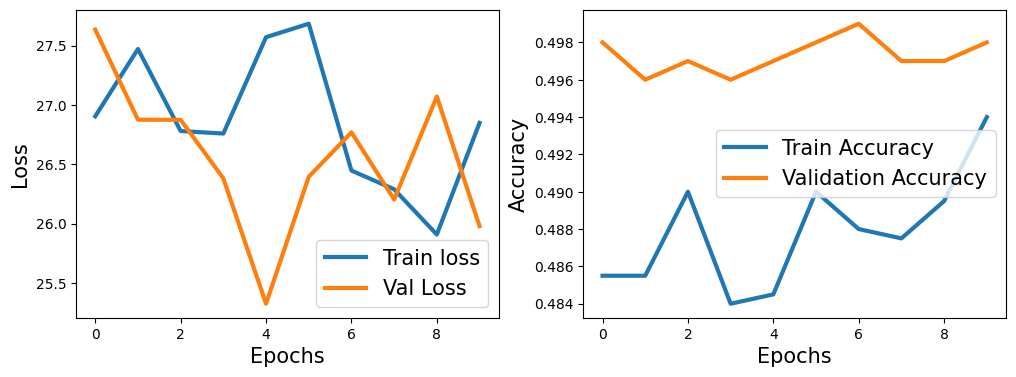

In [ ]:
plot_fig(history_efficient_net)

in above image we can see the model is overfitting, the reson being the image size being set to (180,180) instead of (224,224) the image size upon which efficient net is trained

After changing image size to (224,224)

In [31]:
history_efficient_net = train_n_test(efficient_net_model, num_epochs, trainloader, validationloader)

Epoch 1 Train accuracy: [tensor(0.6165), 0, 0, 0, 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.6830), 0, 0, 0, 0, 0, 0, 0, 0, 0]
Epoch 2 Train accuracy: [tensor(0.6165), tensor(0.7515), 0, 0, 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.6830), tensor(0.7640), 0, 0, 0, 0, 0, 0, 0, 0]
Epoch 3 Train accuracy: [tensor(0.6165), tensor(0.7515), tensor(0.7900), 0, 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.6830), tensor(0.7640), tensor(0.7790), 0, 0, 0, 0, 0, 0, 0]
Epoch 4 Train accuracy: [tensor(0.6165), tensor(0.7515), tensor(0.7900), tensor(0.8070), 0, 0, 0, 0, 0, 0] val accuracy: [tensor(0.6830), tensor(0.7640), tensor(0.7790), tensor(0.8100), 0, 0, 0, 0, 0, 0]
Epoch 5 Train accuracy: [tensor(0.6165), tensor(0.7515), tensor(0.7900), tensor(0.8070), tensor(0.8465), 0, 0, 0, 0, 0] val accuracy: [tensor(0.6830), tensor(0.7640), tensor(0.7790), tensor(0.8100), tensor(0.8360), 0, 0, 0, 0, 0]
Epoch 6 Train accuracy: [tensor(0.6165), tensor(0.7515), tensor(0.7900), tensor(0.8070), tensor(0.8465), tenso

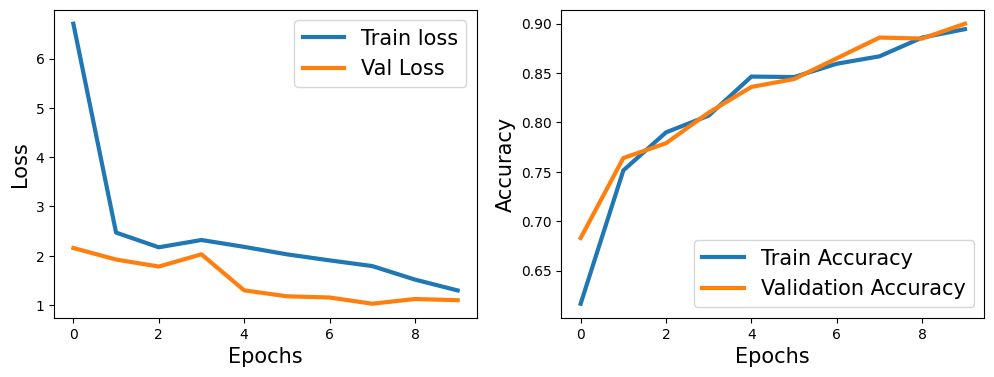

In [32]:
plot_fig(history_efficient_net)